In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
import warnings
from pandas import MultiIndex #, Int64Index # changed
warnings.filterwarnings('ignore')
import os

In [73]:
df = pd.read_pickle("data_Diabetes2.pkl")

In [74]:
print(df.head(10))

   Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0      148             72             35        0  33.6   
1       85             66             29        0  26.6   
2      183             64              0        0  23.3   
3       89             66             23       94  28.1   
4      137             40             35      168  43.1   
5      116             74              0        0  25.6   
6       78             50             32       88  31.0   
7      115              0              0        0  35.3   
8      197             70             45      543  30.5   
9      125             96              0        0   0.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
5                     0.201   30        0  
6                     0.248   26        1 

In [75]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Glucose                   768 non-null    int16  
 1   BloodPressure             768 non-null    int8   
 2   SkinThickness             768 non-null    int8   
 3   Insulin                   768 non-null    int16  
 4   BMI                       768 non-null    float64
 5   DiabetesPedigreeFunction  768 non-null    float64
 6   Age                       768 non-null    int8   
 7   Outcome                   768 non-null    int8   
dtypes: float64(2), int16(2), int8(4)
memory usage: 18.1 KB
None


# 5. Label encoding + Data split: train + test

- Label are already encoded

### Test-train split
- Now we split the DS in train and test. The train size is 66%, and the rest is test DS.

- By randomly rearranging the data points(i.e. shuffling), you can avoid biases, improve generalization, and make your models more robust


In [76]:
X = df[["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]]
y = df["Outcome"]

print(X)
print(y)

     Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0        148             72             35        0  33.6   
1         85             66             29        0  26.6   
2        183             64              0        0  23.3   
3         89             66             23       94  28.1   
4        137             40             35      168  43.1   
..       ...            ...            ...      ...   ...   
763      101             76             48      180  32.9   
764      122             70             27        0  36.8   
765      121             72             23      112  26.2   
766      126             60              0        0  30.1   
767       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  
2                       0.672   32  
3                       0.167   21  
4                       2.288   33  
..                        ...  ...  
763     

In [77]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, train_size=0.66, shuffle=True, random_state=42)

In [78]:
print(X_train.shape)
print(X_test.shape)

(506, 7)
(262, 7)


# 6. Data Preprocessing and Feature Engineering


## Missing Value Treatment (OPTIONAL: Can be Skipped for now)

In [79]:
print(X_train.describe())

          Glucose  BloodPressure  SkinThickness     Insulin         BMI  \
count  506.000000     506.000000     506.000000  506.000000  506.000000   
mean   121.341897      69.924901      20.618577   79.112648   31.997431   
std     32.510222      18.060358      15.499434  115.773786    7.664769   
min      0.000000       0.000000       0.000000    0.000000    0.000000   
25%     99.000000      64.000000       0.000000    0.000000   27.000000   
50%    117.000000      72.000000      23.000000   34.000000   32.000000   
75%    140.000000      80.000000      32.000000  125.750000   36.500000   
max    199.000000     122.000000      63.000000  846.000000   67.100000   

       DiabetesPedigreeFunction         Age  
count                506.000000  506.000000  
mean                   0.469749   33.126482  
std                    0.341455   11.713909  
min                    0.078000   21.000000  
25%                    0.241750   24.000000  
50%                    0.380500   29.000000  
75

In [80]:
# Lets look at test data
print(X_test.describe())

          Glucose  BloodPressure  SkinThickness     Insulin         BMI  \
count  262.000000     262.000000     262.000000  262.000000  262.000000   
mean   120.030534      67.522901      20.377863   81.125954   31.983206   
std     30.950817      21.588219      16.821532  114.422803    8.306528   
min      0.000000       0.000000       0.000000    0.000000    0.000000   
25%     99.000000      60.000000       0.000000    0.000000   27.850000   
50%    115.000000      72.000000      23.000000   26.000000   32.650000   
75%    140.750000      78.000000      33.000000  129.500000   36.600000   
max    197.000000     114.000000      99.000000  680.000000   57.300000   

       DiabetesPedigreeFunction         Age  
count                262.000000  262.000000  
mean                   0.475985   33.461832  
std                    0.311434   11.868552  
min                    0.088000   21.000000  
25%                    0.245250   24.000000  
50%                    0.364500   29.000000  
75

In [81]:
print(X_train.isnull().sum())

# It **seems** that there are no missing values in the dataset. This actually is not true.
# - 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI' should not have 0 values.

Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [88]:
# Replace 0 with Nan
X_train_copy = X_train.copy(deep=True)
X_train_copy[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] \
= X_train_copy[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, np.nan)

X_test[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] \
= X_test[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, np.nan)


# Showing the count of NaNs
print("Count of null values for train:\n", X_train_copy.isnull().sum(), "\n")
print("Count of null values for test:\n", X_test.isnull().sum())

Count of null values for train:
 Glucose                       4
BloodPressure                18
SkinThickness               143
Insulin                     247
BMI                           5
DiabetesPedigreeFunction      0
Age                           0
dtype: int64 

Count of null values for test:
 Glucose                       1
BloodPressure                17
SkinThickness                84
Insulin                     127
BMI                           6
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


array([[<Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>],
       [<Axes: title={'center': 'BMI'}>, <Axes: >]], dtype=object)

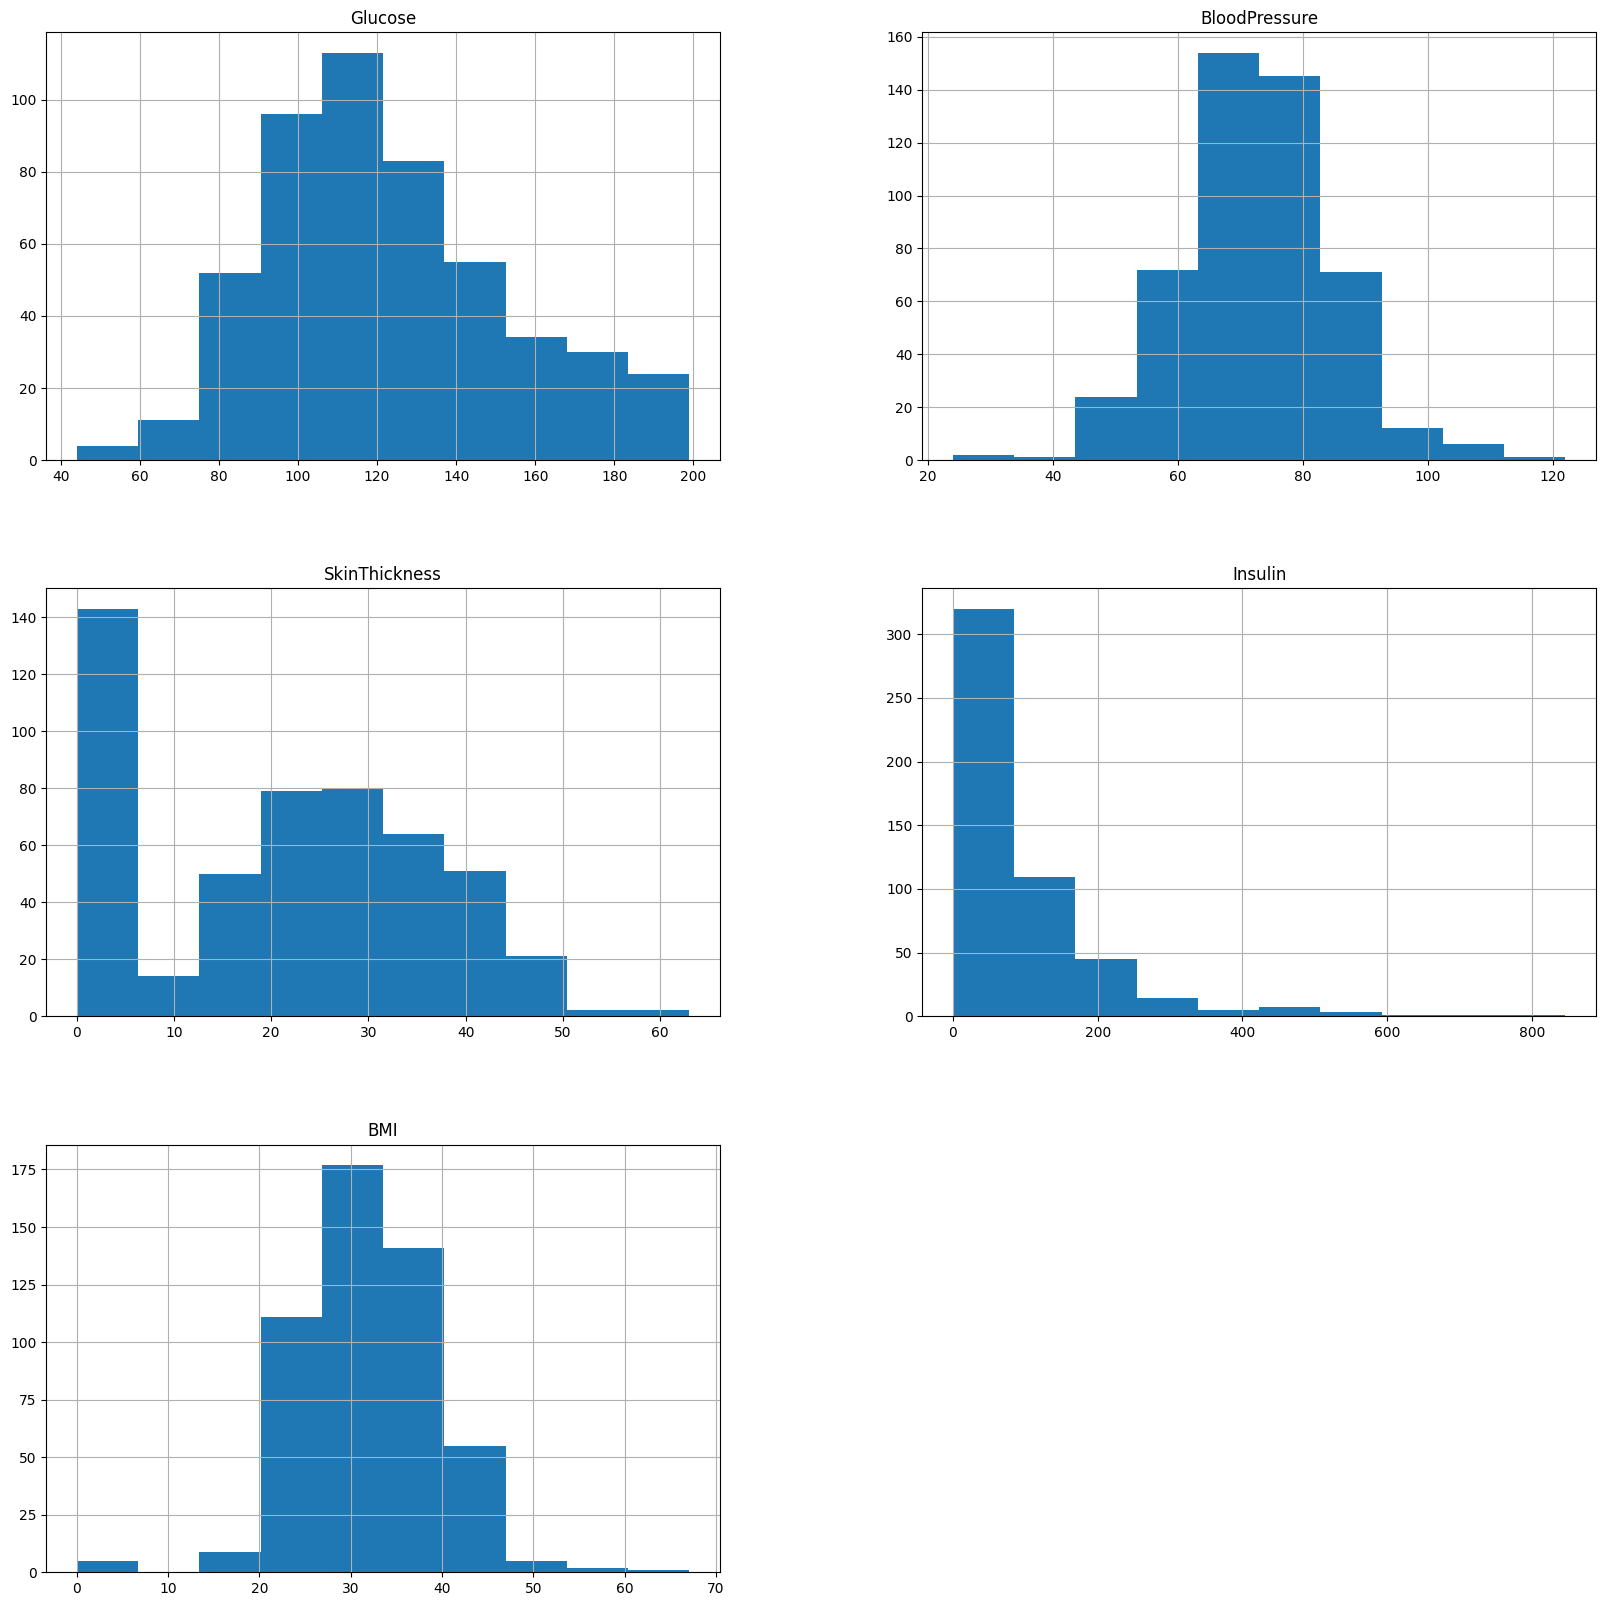

In [89]:
# First, let’s visualize the distribution of features 'Glucose', 'BloodPressure', 'SkinThickness', 
# 'Insulin', 'BMI' in the dataset **before** removing null values:

X_train[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].hist(figsize=(20, 20))

So here, we have seen the distribution of each feature, whether dependent or independent. We plot the histogram because it shows the occurrence of every value, letting us know the range of the data.

Imputing Missing Values

Now, we will handle the missing values. 
- We can use the KNN / mean value for ‘Glucose’ and ‘BloodPressure’. For reason why, see KDE plot below (before/after)
- We’ll use the median value for ‘SkinThickness’’ ‘Insulin’’ and ‘BMI’:

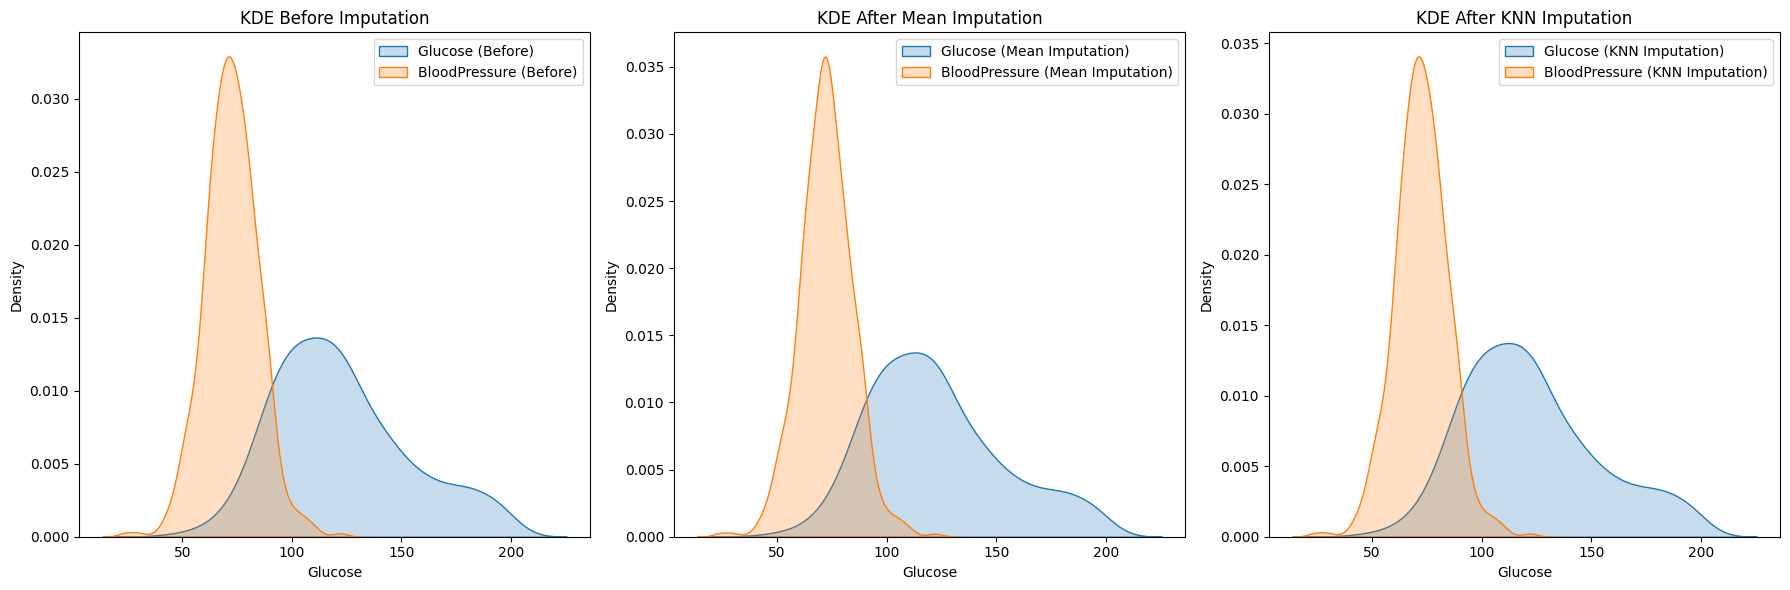

In [90]:
from sklearn.impute import KNNImputer

# Columns with invalid zero values
zero_columns = ['Glucose', 'BloodPressure'] #'SkinThickness', 'Insulin', 'BMI']

# Store original data (before imputation)
X_train_before = X_train.copy()

# Replace zeroes with NaN before imputation
X_train[zero_columns] = X_train[zero_columns].replace(0, np.nan)

# Apply Mean Imputation
X_train_mean = X_train.copy()
for col in zero_columns:
    X_train_mean[col] = X_train_mean[col].fillna(X_train_mean[col].mean())

# Apply KNN Imputation
imputer = KNNImputer(n_neighbors=5)
X_train_knn = X_train.copy()
X_train_knn[zero_columns] = imputer.fit_transform(X_train_knn[zero_columns])

# Create Subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Before Imputation
for col in zero_columns:
    sns.kdeplot(X_train_before[col], label=f"{col} (Before)", fill=True, ax=axes[0])
axes[0].set_title("KDE Before Imputation")
axes[0].legend()

# After Mean Imputation
for col in zero_columns:
    sns.kdeplot(X_train_mean[col], label=f"{col} (Mean Imputation)", fill=True, ax=axes[1])
axes[1].set_title("KDE After Mean Imputation")
axes[1].legend()

# After KNN Imputation
for col in zero_columns:
    sns.kdeplot(X_train_knn[col], label=f"{col} (KNN Imputation)", fill=True, ax=axes[2])
axes[2].set_title("KDE After KNN Imputation")
axes[2].legend()

# Adjust layout
plt.tight_layout()
plt.show()


# We notice that KDE graph after imputation  with KNN or mean values is similar. 
# So I will choose mean imputation here because it is computationally inexpensive compared with KNN.

In [91]:
X_train_copy['Glucose'].fillna(X_train_copy['Glucose'].mean(), inplace=True)
X_train_copy['BloodPressure'].fillna(X_train_copy['BloodPressure'].mean(), inplace=True)

# Do the same for test data:
X_test['Glucose'].fillna(X_test['Glucose'].mean(), inplace=True)
X_test['BloodPressure'].fillna(X_test['BloodPressure'].mean(), inplace=True)


# Showing the count of NaNs
print("Count of null values for train:\n", X_train_copy.isnull().sum(), "\n")
print("Count of null values for test:\n", X_test.isnull().sum())

Count of null values for train:
 Glucose                       0
BloodPressure                 0
SkinThickness               143
Insulin                     247
BMI                           5
DiabetesPedigreeFunction      0
Age                           0
dtype: int64 

Count of null values for test:
 Glucose                       0
BloodPressure                 0
SkinThickness                84
Insulin                     127
BMI                           6
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


### Now lets handle 'SkinThickness', 'Insulin', 'BMI'

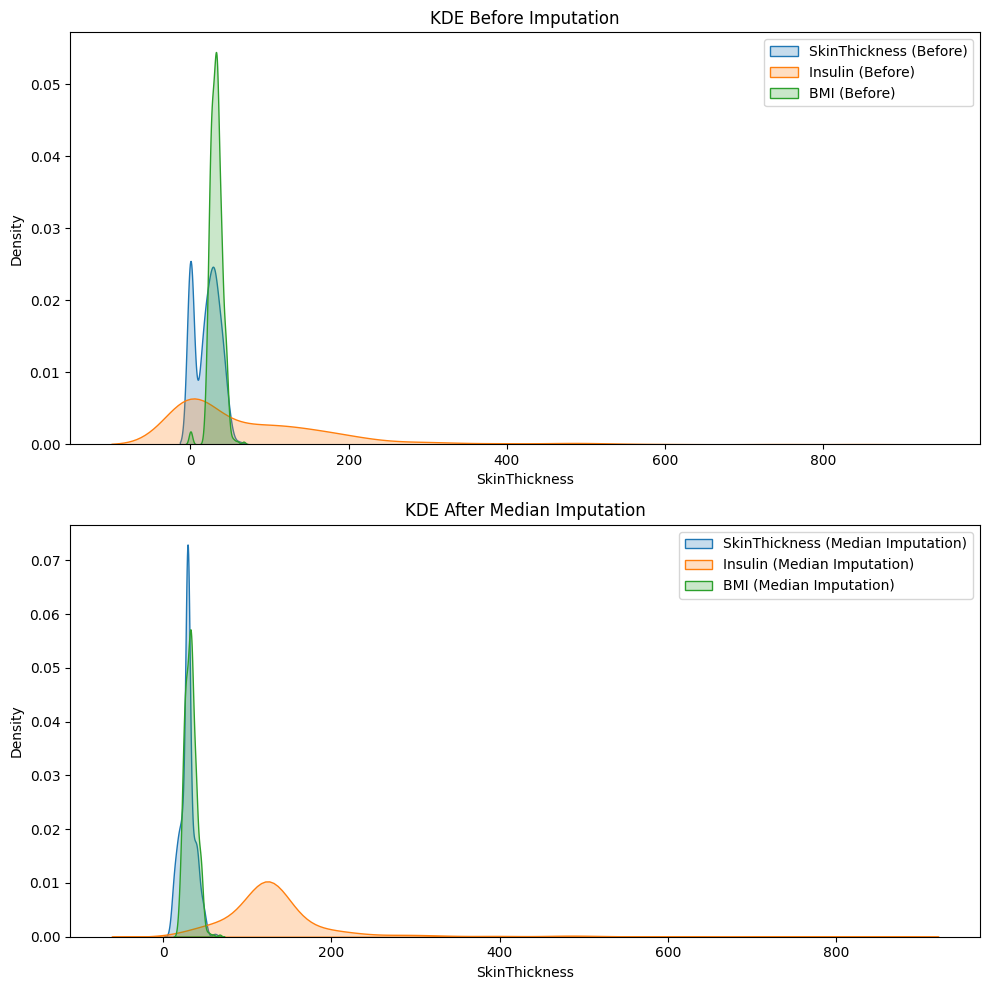

In [92]:
# Columns with invalid zero values
zero_columns = ['SkinThickness', 'Insulin', 'BMI']

# Store original data (before imputation)
X_train_before = X_train.copy()

# Replace zeroes with NaN before imputation
X_train[zero_columns] = X_train[zero_columns].replace(0, np.nan)

# Apply Median Imputation
X_train_median = X_train.copy()
for col in zero_columns:
    X_train_median[col] = X_train_median[col].fillna(X_train_median[col].median())

# Create Subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Before Imputation
for col in zero_columns:
    sns.kdeplot(X_train_before[col], label=f"{col} (Before)", fill=True, ax=axes[0])
axes[0].set_title("KDE Before Imputation")
axes[0].legend()

# After Median Imputation
for col in zero_columns:
    sns.kdeplot(X_train_median[col], label=f"{col} (Median Imputation)", fill=True, ax=axes[1])
axes[1].set_title("KDE After Median Imputation")
axes[1].legend()

# Adjust layout
plt.tight_layout()
plt.show()

#### Based on above plot, we see that we should use median to replace the 0 vlaues in  'SkinThickness', 'Insulin', 'BMI'

In [93]:
# Showing the count of NaNs
print("BEFORE####################")
print(X_train_copy.isnull().sum())

X_train_copy['SkinThickness'].fillna(X_train_copy['SkinThickness'].median(), inplace=True)
X_train_copy['Insulin'].fillna(X_train_copy['Insulin'].median(), inplace=True)
X_train_copy['BMI'].fillna(X_train_copy['BMI'].median(), inplace=True)


#Do the same for test data
X_test['SkinThickness'].fillna(X_test['SkinThickness'].median(), inplace=True)
X_test['Insulin'].fillna(X_test['Insulin'].median(), inplace=True)
X_test['BMI'].fillna(X_test['BMI'].median(), inplace=True)


# Showing the count of NaNs
print("AFTER####################")
print("Count of null values for train:\n", X_train_copy.isnull().sum(), "\n")
print("Count of null values for test:\n", X_test.isnull().sum())
X_train = X_train_copy

BEFORE####################
Glucose                       0
BloodPressure                 0
SkinThickness               143
Insulin                     247
BMI                           5
DiabetesPedigreeFunction      0
Age                           0
dtype: int64
AFTER####################
Count of null values for train:
 Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64 

Count of null values for test:
 Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


# Outliers treatment (SKIP FOR NOW. WORK ON THIS LATER)
TODO later

<Axes: title={'center': 'Age'}>

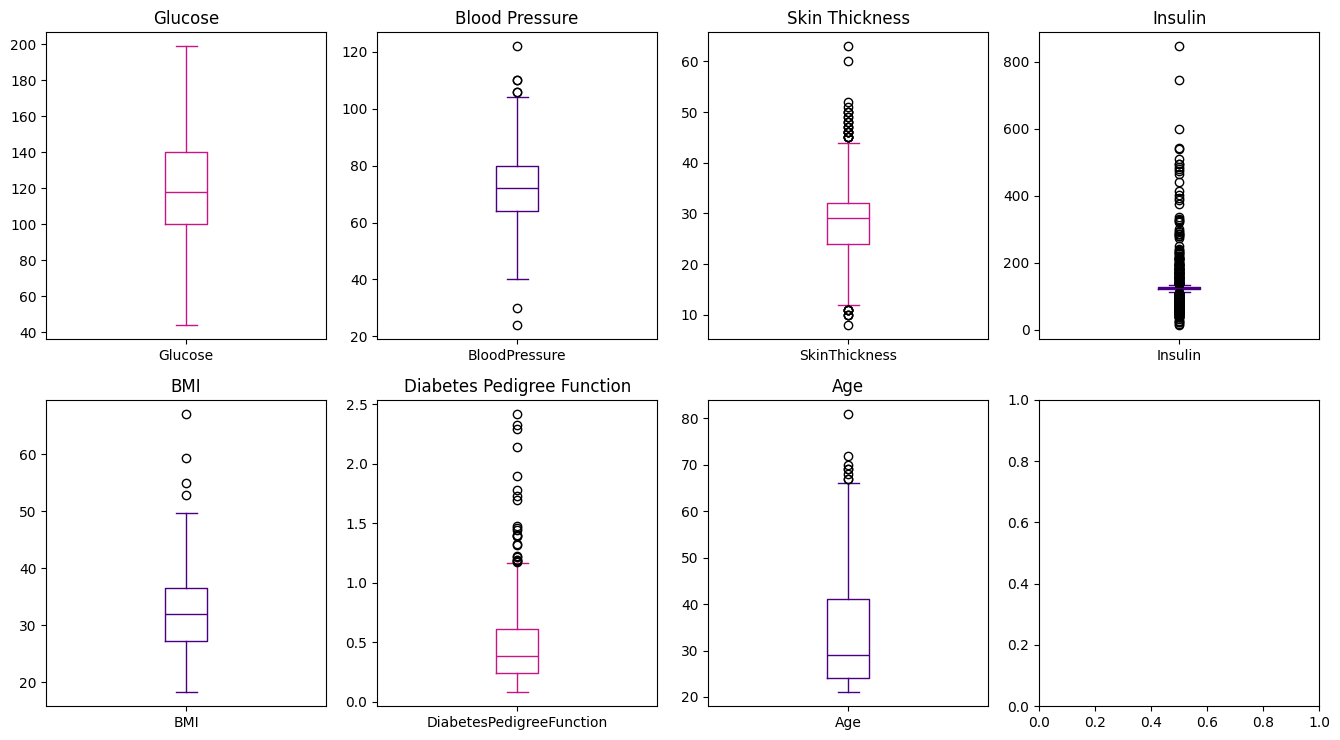

In [95]:
# Step1: Identfy outliers

plt.rcParams["figure.figsize"] = [13.50, 7.50]
plt.rcParams["figure.autolayout"] = True
figure, axis = plt.subplots(2, 4)
  
X_train['Glucose'].plot.box(title="Glucose",ax=axis[0][0],color="MEDIUMVIOLETRED")
X_train['BloodPressure'].plot.box(title="Blood Pressure",ax=axis[0][1],color="INDIGO")
X_train['SkinThickness'].plot.box(title="Skin Thickness",ax=axis[0][2],color="MEDIUMVIOLETRED")
X_train['Insulin'].plot.box(title="Insulin",ax=axis[0][3],color="INDIGO")
X_train['BMI'].plot.box(title="BMI",ax=axis[1][0],color="INDIGO")
X_train['DiabetesPedigreeFunction'].plot.box(title="Diabetes Pedigree Function",ax=axis[1][1],color="MEDIUMVIOLETRED")
X_train['Age'].plot.box(title="Age",ax=axis[1][2],color="INDIGO")


In [99]:
# Lets print outliers values:
colummns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

for col in columns:
    
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]
    print(outliers)
    print("+++++++\n")

Empty DataFrame
Columns: [Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]
Index: []
+++++++

     Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
43     171.0          110.0           24.0    240.0  45.4   
177    129.0          110.0           46.0    130.0  67.1   
125     88.0           30.0           42.0     99.0  55.0   
672     68.0          106.0           23.0     49.0  35.5   
597     89.0           24.0           19.0     25.0  27.8   
658    127.0          106.0           29.0    125.0  39.0   
106     96.0          122.0           29.0    125.0  22.4   

     DiabetesPedigreeFunction  Age  
43                      0.721   54  
177                     0.319   26  
125                     0.496   26  
672                     0.285   47  
597                     0.559   21  
658                     0.190   51  
106                     0.207   27  
+++++++

     Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
177    129.0    

 ## Outlier treatments
 1. Detect Outliers: To detect outliers in pandas, you typically begin by calculating summary statistics like the mean and standard deviation. Then, determine a threshold, commonly set to values more than 3 standard deviations from the mean. Use the abs(df - df.mean()) > (3 * df.std()) code snippet to flag outliers in your DataFrame. This boolean mask can then be used to filter out the anomalous data points for further inspection.
 
 2. Visualize Data: Visualization is a key step in outlier detection. Plotting your data using histograms or boxplots can reveal outliers visually. In pandas, you can employ df.plot(kind='box') to generate a boxplot, which displays the median, quartiles, and fliers that may be potential outliers. These plots make it easier to identify data points that fall outside the typical range of values.
 
 3. Z-Score Method: The Z-score method standardizes your data, showing how many standard deviations each point is from the mean. In pandas, you can calculate the Z-score using scipy.stats.zscore(df) . Typically, a Z-score above 3 or below -3 is considered an outlier. This method is particularly effective for datasets that follow a normal distribution.

 4. IQR Technique: The Interquartile Range (IQR) technique is another robust method for identifying outliers. Calculate the IQR by subtracting the first quartile (Q1) from the third quartile (Q3). Then, find outliers by looking for data points that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR . Pandas allows you to compute these quartiles and apply these criteria to filter out the outliers.

 5. Correct Outliers: Once outliers are identified, you have several options for correction. You can remove them using df = df[~outlier_mask] or replace them with a central tendency measure like the mean or median. Alternatively, outliers can be capped at a certain value with df[df > upper_bound] = upper_value . This correction approach should be chosen based on the context and impact on your analysis

**In our case we handle outliers in all columns of a DataFrame df by replacing values that are considered outliers with the mean of that column.**

In [102]:
columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin",
           "BMI", "DiabetesPedigreeFunction", "Age"]

for col in columns:
    Q1 = X_train.Glucose.quantile(0.25)
    Q3 = X_train.Glucose.quantile(0.75)
    IQR = Q3-Q1
    lower_limit = Q1-1.5*IQR
    upper_limit = Q3+1.5*IQR
    X_train.loc[X_train[col]<=lower_limit,col] = np.mean(X_train[col])
    X_train.loc[X_train[col]>upper_limit, col] = np.mean(X_train[col])

In [103]:
# Lets print outliers values:
colummns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

for col in columns:
    
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]
    print(outliers)
    print("+++++++\n")

Empty DataFrame
Columns: [Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]
Index: []
+++++++

     Glucose  BloodPressure  SkinThickness     Insulin        BMI  \
43     171.0          110.0      30.405341  142.540385  45.400000   
177    129.0          110.0      46.000000  130.000000  67.100000   
440    189.0          104.0      30.405341  125.000000  32.313636   
672     68.0          106.0      30.405341   49.000000  32.313636   
207    162.0          104.0      30.405341  125.000000  32.313636   
658    127.0          106.0      30.405341  125.000000  32.313636   
106     96.0          122.0      30.405341  125.000000  32.313636   

     DiabetesPedigreeFunction        Age  
43                   0.469749  54.000000  
177                  0.469749  33.126482  
440                  0.469749  41.000000  
672                  0.469749  47.000000  
207                  0.469749  52.000000  
658                  0.469749  51.000000  
106              

<Axes: title={'center': 'Age'}>

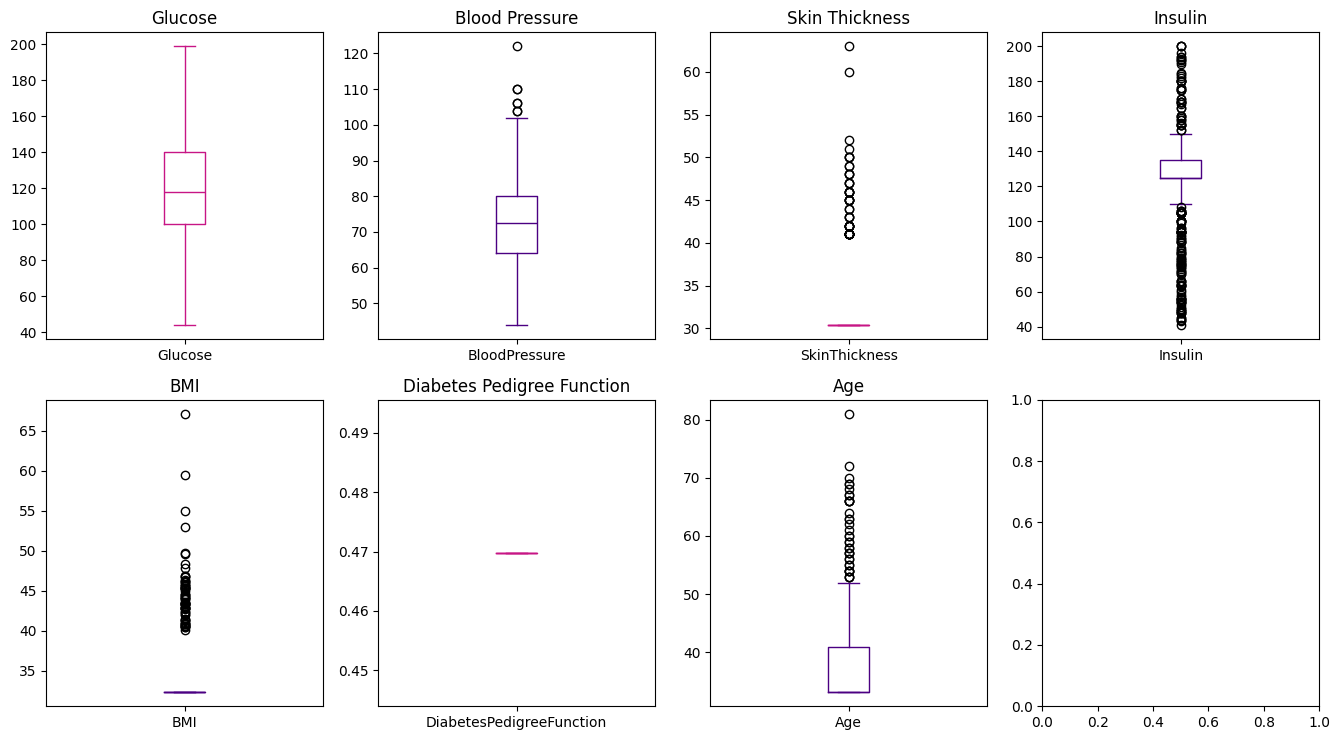

In [104]:
plt.rcParams["figure.figsize"] = [13.50, 7.50]
plt.rcParams["figure.autolayout"] = True
figure, axis = plt.subplots(2, 4)
  
X_train['Glucose'].plot.box(title="Glucose",ax=axis[0][0],color="MEDIUMVIOLETRED")
X_train['BloodPressure'].plot.box(title="Blood Pressure",ax=axis[0][1],color="INDIGO")
X_train['SkinThickness'].plot.box(title="Skin Thickness",ax=axis[0][2],color="MEDIUMVIOLETRED")
X_train['Insulin'].plot.box(title="Insulin",ax=axis[0][3],color="INDIGO")
X_train['BMI'].plot.box(title="BMI",ax=axis[1][0],color="INDIGO")
X_train['DiabetesPedigreeFunction'].plot.box(title="Diabetes Pedigree Function",ax=axis[1][1],color="MEDIUMVIOLETRED")
X_train['Age'].plot.box(title="Age",ax=axis[1][2],color="INDIGO")


## Scaling continuous variables
- Standardization involves scaling the features such that they have a mean of 0 and a standard deviation of 1. This is useful when features have different units or magnitudes and ensures they are treated equally when used in machine learning models.

- method scaler.fit_transform(df_X) does two things:

fit() computes the mean and standard deviation of each column (feature) in df_X to understand the distribution of the data.

transform() scales each feature in df_X by subtracting the mean and dividing by the standard deviation, effectively standardizing each feature.

In [157]:
scaler = StandardScaler()
# X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_copy),columns=X_train_copy.columns)
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [158]:
print(X_train_scaled)

[[-1.11896686  0.44755979 -1.33159583 ... -0.10414142 -0.25723968
   0.75826946]
 [-1.05738687 -0.5500845  -0.16911382 ... -1.33174556 -0.07548424
  -1.0362453 ]
 [-0.47237695  0.55840916 -1.33159583 ... -1.09667243 -0.9754668
   0.92917563]
 ...
 [-0.62632693  0.89095725  1.05795053 ...  1.77644363  1.95314095
   0.41645712]
 [ 0.6052729  -3.87556548 -1.33159583 ...  1.35853584 -0.77612213
  -0.35262063]
 [ 0.11263297  1.44520408 -1.33159583 ... -1.24032823 -0.60902439
  -1.0362453 ]]


# 7. Modeling + Training


### Logistic Regression

In [159]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report

lr = LogisticRegression(random_state=16)
lr.fit(X_train_scaled, Y_train)
Y_pred = lr.predict(X_test_scaled)

confusion_matrix = metrics.confusion_matrix(Y_test, Y_pred)
print("-"*70)
print("Report")
print("-"*70)
print("Confusion Matrix:")
print(str(confusion_matrix))
target_names = ['without diabetes', 'with diabetes']
acc=(confusion_matrix[0][0] + confusion_matrix[1][1])/(confusion_matrix[0][0]+confusion_matrix[0][1]+confusion_matrix[1][0]+confusion_matrix[1][1])
print("Accuracy by confusion matrix: "+str(acc))
print("\n")
print(classification_report(Y_test, Y_pred, target_names=target_names))
print("-"*70)

----------------------------------------------------------------------
Report
----------------------------------------------------------------------
Confusion Matrix:
[[144  30]
 [ 37  51]]
Accuracy by confusion matrix: 0.7442748091603053


                  precision    recall  f1-score   support

without diabetes       0.80      0.83      0.81       174
   with diabetes       0.63      0.58      0.60        88

        accuracy                           0.74       262
       macro avg       0.71      0.70      0.71       262
    weighted avg       0.74      0.74      0.74       262

----------------------------------------------------------------------


### Naive Bayes

In [160]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_scaled, Y_train)
Y_pred = gnb.predict(X_test_scaled)

confusion_matrix = metrics.confusion_matrix(Y_test, Y_pred)
print("-"*70)
print("Report")
print("-"*70)
print("Confusion Matrix:")
print(str(confusion_matrix))
target_names = ['without diabetes', 'with diabetes']
acc=(confusion_matrix[0][0] + confusion_matrix[1][1])/(confusion_matrix[0][0]+confusion_matrix[0][1]+confusion_matrix[1][0]+confusion_matrix[1][1])
print("Accuracy by confusion matrix: "+str(acc))
print("\n")
print(classification_report(Y_test, Y_pred, target_names=target_names))
print("-"*70)

----------------------------------------------------------------------
Report
----------------------------------------------------------------------
Confusion Matrix:
[[141  33]
 [ 39  49]]
Accuracy by confusion matrix: 0.7251908396946565


                  precision    recall  f1-score   support

without diabetes       0.78      0.81      0.80       174
   with diabetes       0.60      0.56      0.58        88

        accuracy                           0.73       262
       macro avg       0.69      0.68      0.69       262
    weighted avg       0.72      0.73      0.72       262

----------------------------------------------------------------------


### K-nearest neighbors

In [161]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, Y_train)
Y_pred = knn.predict(X_test_scaled)

confusion_matrix = metrics.confusion_matrix(Y_test, Y_pred)
print("-"*70)
print("Report")
print("-"*70)
print("Confusion Matrix:")
print(str(confusion_matrix))
target_names = ['without diabetes', 'with diabetes']
acc=(confusion_matrix[0][0] + confusion_matrix[1][1])/(confusion_matrix[0][0]+confusion_matrix[0][1]+confusion_matrix[1][0]+confusion_matrix[1][1])
print("Accuracy by confusion matrix: "+str(acc))
print("\n")
print(classification_report(Y_test, Y_pred, target_names=target_names))
print("-"*70)

----------------------------------------------------------------------
Report
----------------------------------------------------------------------
Confusion Matrix:
[[136  38]
 [ 39  49]]
Accuracy by confusion matrix: 0.7061068702290076


                  precision    recall  f1-score   support

without diabetes       0.78      0.78      0.78       174
   with diabetes       0.56      0.56      0.56        88

        accuracy                           0.71       262
       macro avg       0.67      0.67      0.67       262
    weighted avg       0.71      0.71      0.71       262

----------------------------------------------------------------------


### Decision tree Classifier

In [162]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, Y_train)
Y_pred = dt.predict(X_test_scaled)

confusion_matrix = metrics.confusion_matrix(Y_test, Y_pred)
print("-"*70)
print("Report")
print("-"*70)
print("Confusion Matrix:")
print(str(confusion_matrix))
target_names = ['without diabetes', 'with diabetes']
acc=(confusion_matrix[0][0] + confusion_matrix[1][1])/(confusion_matrix[0][0]+confusion_matrix[0][1]+confusion_matrix[1][0]+confusion_matrix[1][1])
print("Accuracy by confusion matrix: "+str(acc))
print("\n")
print(classification_report(Y_test, Y_pred, target_names=target_names))
print("-"*70)

----------------------------------------------------------------------
Report
----------------------------------------------------------------------
Confusion Matrix:
[[128  46]
 [ 31  57]]
Accuracy by confusion matrix: 0.7061068702290076


                  precision    recall  f1-score   support

without diabetes       0.81      0.74      0.77       174
   with diabetes       0.55      0.65      0.60        88

        accuracy                           0.71       262
       macro avg       0.68      0.69      0.68       262
    weighted avg       0.72      0.71      0.71       262

----------------------------------------------------------------------


### Support Vector Classifier

In [163]:
from sklearn import svm

svm = svm.SVC(kernel='poly') 
svm.fit(X_train_scaled, Y_train)
Y_pred = svm.predict(X_test_scaled)

confusion_matrix = metrics.confusion_matrix(Y_test, Y_pred)
print("-"*70)
print("Report")
print("-"*70)
print("Confusion Matrix:")
print(str(confusion_matrix))
target_names = ['without diabetes', 'with diabetes']
acc=(confusion_matrix[0][0] + confusion_matrix[1][1])/(confusion_matrix[0][0]+confusion_matrix[0][1]+confusion_matrix[1][0]+confusion_matrix[1][1])
print("Accuracy by confusion matrix: "+str(acc))
print("\n")
print(classification_report(Y_test, Y_pred, target_names=target_names))
print("-"*70)

----------------------------------------------------------------------
Report
----------------------------------------------------------------------
Confusion Matrix:
[[156  18]
 [ 51  37]]
Accuracy by confusion matrix: 0.7366412213740458


                  precision    recall  f1-score   support

without diabetes       0.75      0.90      0.82       174
   with diabetes       0.67      0.42      0.52        88

        accuracy                           0.74       262
       macro avg       0.71      0.66      0.67       262
    weighted avg       0.73      0.74      0.72       262

----------------------------------------------------------------------


### Random Forest Classifier

In [164]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=200,random_state=42)
rfc.fit(X_train_scaled, Y_train)

Y_pred = rfc.predict(X_test_scaled)
confusion_matrix = metrics.confusion_matrix(Y_test, Y_pred)
print("-"*70)
print("Report")
print("-"*70)
print("Confusion Matrix:")
print(str(confusion_matrix))
target_names = ['without diabetes', 'with diabetes']
acc=(confusion_matrix[0][0] + confusion_matrix[1][1])/(confusion_matrix[0][0]+confusion_matrix[0][1]+confusion_matrix[1][0]+confusion_matrix[1][1])
print("Accuracy by confusion matrix: "+str(acc))
print("\n")
print(classification_report(Y_test, Y_pred, target_names=target_names))
print("-"*70)

----------------------------------------------------------------------
Report
----------------------------------------------------------------------
Confusion Matrix:
[[138  36]
 [ 30  58]]
Accuracy by confusion matrix: 0.7480916030534351


                  precision    recall  f1-score   support

without diabetes       0.82      0.79      0.81       174
   with diabetes       0.62      0.66      0.64        88

        accuracy                           0.75       262
       macro avg       0.72      0.73      0.72       262
    weighted avg       0.75      0.75      0.75       262

----------------------------------------------------------------------


### conclusion
Accuracy for each of above models:
- Log regression : 74.4%
- Naive Bayes    : 70.9%
- KNN            : 69.0%
- Decision Tree  : 70.2%
- SVC            : 72.9%
- Random Frst. Cl: 74.8%

**It seems RFC does better among all, and next best model is Log Regression.**
**Lets keep RFC.**

Index(['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
       'DiabetesPedigreeFunction', 'Age'],
      dtype='object')


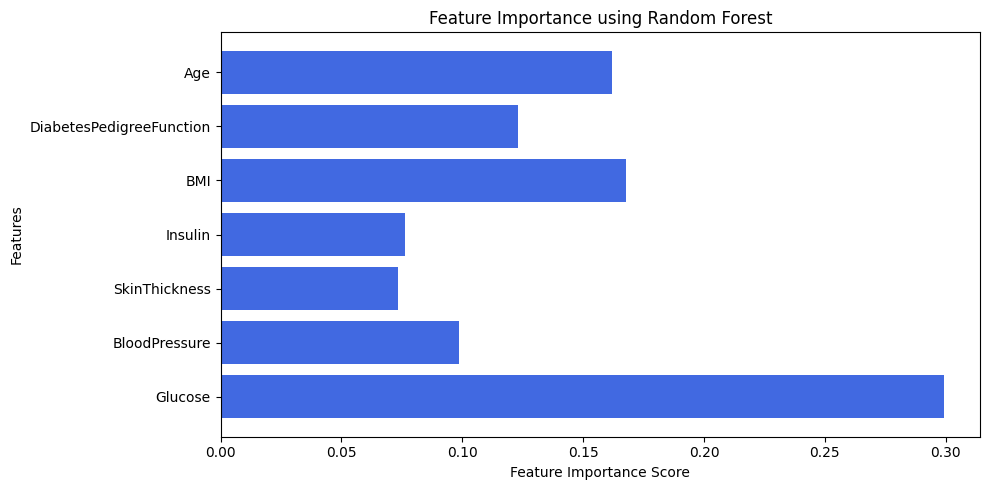

In [168]:
# Lets read Feature Importance
importances = rfc.feature_importances_
feature_names = df.columns[:-1]
print(feature_names)

# Plot Feature Importance
plt.figure(figsize=(10, 5))
plt.barh(feature_names, importances, color='royalblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance using Random Forest")
plt.show()

It seems that RFC views Glucose most important feature, and then there is BMI, Age and DiabetesPedigreeFunction. Visualizing feature importance helps us identify which features influence the model’s predictions most.

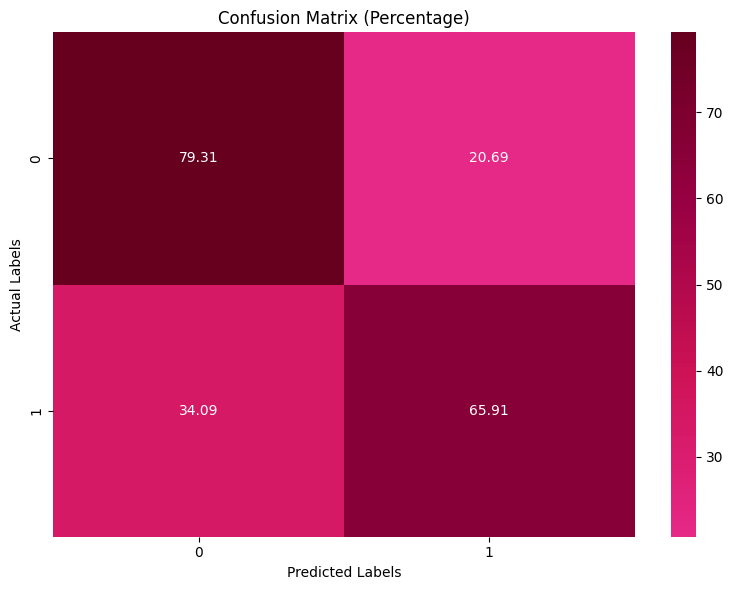

In [169]:
# Lets plot confusion matrix

Y_pred = rfc.predict(X_test_scaled)
conf_matrix = metrics.confusion_matrix(Y_test, Y_pred)

# Convert to percentages
conf_matrix_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1, keepdims=True) * 100

# Define class labels
class_names = np.unique(Y_test)  # Extract unique class names


# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_percent, # or use conf_matrix if you want to see the actual numbers
            annot=True, fmt=".2f",
            cmap='PuRd', center=0,
            xticklabels=class_names,
            yticklabels=class_names)

# Labels and title
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix (Percentage)")
plt.show()

## Lets save the model

In [170]:
import pickle
pickle.dump(rfc, open('model_saved/rfc.pkl','wb')) #Save the model for future